In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data_dir = "F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/helene89pervmax/"
nc_path = data_dir+"hurrywave_sp2.nc"
ds = xr.open_dataset(nc_path, mask_and_scale=True, decode_cf=True)
ds

<xarray.Dataset> Size: 85MB
Dimensions:           (stations: 425, sigma: 12, theta: 36, time: 115,
                       runtime: 1)
Coordinates:
  * sigma             (sigma) float32 48B 0.04 0.05032 0.06331 ... 0.3974 0.5
  * theta             (theta) float32 144B 5.0 15.0 25.0 ... 335.0 345.0 355.0
  * time              (time) datetime64[ns] 920B 2024-09-23 ... 2024-09-27T18...
Dimensions without coordinates: stations, runtime
Data variables:
    inp               int32 4B ...
    station_id        (stations) float32 2kB ...
    station_name      (stations) |S256 109kB ...
    station_x         (stations) float32 2kB ...
    station_y         (stations) float32 2kB ...
    crs               int32 4B ...
    point_spectrum2d  (time, stations, theta, sigma) float32 84MB ...
    total_runtime     (runtime) float32 4B ...
    average_dt        (runtime) float32 4B ...
Attributes:
    Conventions:                         Conventions = 'CF-1.6, SGRID-0.3
    Build-Revision-Date-Netcdf-library:  4.9.2 of Mar 14 2023 15:42:34 $
    Producer:                            HURRYWAVE
    Build-Revision:                      $Rev: xxx $
    Build-Date:                          $Date: 2024-06-18$
    title:                               HURRYWAVE 2D spectrum point output

In [2]:
# load bulk paramters from the .his file
hisfile = data_dir+"hurrywave_his.nc"
ds_his = xr.open_dataset(hisfile)
ds_his

<xarray.Dataset> Size: 7MB
Dimensions:         (stations: 435, time: 685, runtime: 1)
Coordinates:
  * time            (time) datetime64[ns] 5kB 2024-09-23 ... 2024-09-27T18:00:00
Dimensions without coordinates: stations, runtime
Data variables: (12/15)
    inp             int32 4B ...
    station_id      (stations) float32 2kB ...
    station_name    (stations) |S256 111kB ...
    station_x       (stations) float32 2kB ...
    station_y       (stations) float32 2kB ...
    station_z       (stations) float32 2kB ...
    ...              ...
    point_wavdir    (time, stations) float32 1MB ...
    point_dirspr    (time, stations) float32 1MB ...
    wind_speed      (time, stations) float32 1MB ...
    wind_direction  (time, stations) float32 1MB ...
    total_runtime   (runtime) float32 4B ...
    average_dt      (runtime) float32 4B ...
Attributes:
    Conventions:                         Conventions = 'CF-1.6, SGRID-0.3
    Build-Revision-Date-Netcdf-library:  4.9.2 of Mar 14 2023 15:42:34 $
    Producer:                            HurryWave
    Build-Revision:                      $Rev: xxx $
    Build-Date:                          $Date: 2024-06-18$
    title:                               HurryWave his point netcdf output

In [3]:
# calculate Hmo from HurryWave spectra
nc_path = data_dir+"hurrywave_sp2.nc"
ds = xr.open_dataset(nc_path, mask_and_scale=True, decode_cf=True)

time = ds['time'].values
freq = ds['sigma'].values # Hz
theta = np.deg2rad( ds['theta'].values ) # radians (converted from degrees)
dtheta = np.abs( theta[1]-theta[0] )
print(dtheta)

S_thf = ds['point_spectrum2d']   # (time, stations, theta, sigma) ]

# integrate over direction (rad) -> m^2 s
S_f = np.sum(S_thf, axis=2)*dtheta

# integrate over frequency (Hz) -> m^2
m0 = np.trapezoid(S_f, freq, axis=-1)

# calculate Hm0
Hm0 = 4 * np.sqrt(m0)

print("m0 min/max:", np.min(m0), np.max(m0))
print("Hm0 min/max:", np.min(Hm0), np.max(Hm0))

0.17453294
m0 min/max: 0.0 2.8296366
Hm0 min/max: 0.0 6.7286096


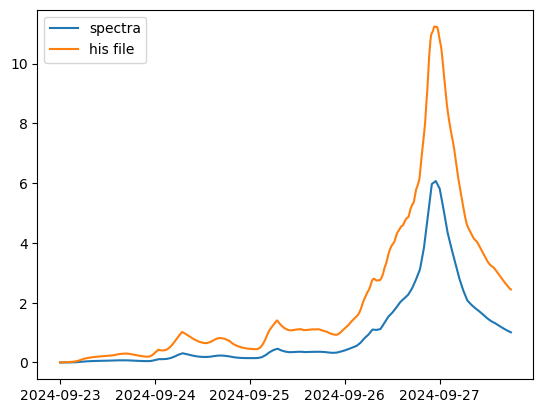

In [4]:
plt.plot( time, Hm0[:,300], label='spectra' )
plt.plot( ds_his['time'], ds_his['point_hm0'][:, 300], label='his file')
plt.legend()

In [5]:
print( 'shape of Hm0 from spectra: ',np.shape( Hm0) )
print( 'shape of hm0 from .his file: ',np.shape( ds_his['point_hm0'] ) )
print( np.max (Hm0), np.max( ds_his['point_hm0']) )
print( np.max (Hm0) / np.max( ds_his['point_hm0']) )

shape of Hm0 from spectra:  (115, 425)
shape of hm0 from .his file:  (685, 435)
6.7286096 <xarray.DataArray 'point_hm0' ()> Size: 4B
array(11.771618, dtype=float32)
<xarray.DataArray 'point_hm0' ()> Size: 4B
array(0.57159597, dtype=float32)


In [8]:
# -----------------------------
# constants
# -----------------------------
g = 9.81
rho = 1025.

# -----------------------------
# load contour + normals
# -----------------------------
contour_file = 'contour30sp.csv'
df = pd.read_csv(contour_file)
normals_x = df['normals30_x'].values
normals_y = df['normals30_y'].values
contour_x = df['contour30s_x'].values
contour_y = df['contour30s_y'].values

# constant depth
h = 30.0

nt, npts, nd, nf = S_thf.shape

# convert direction FROM -> TO
theta_to = np.deg2rad( np.rad2deg(theta) + 180. % 360. )
# unit vectors for each direction bin
ux = np.sin(theta_to)
uy = np.cos(theta_to)

# -----------------------------
# dispersion → group velocity
# -----------------------------
omega = 2*np.pi*freq

def solve_k(omega, h):
    k = omega**2/g
    for _ in range(20):
        kh = k*h
        t = np.tanh(kh)
        fval = g*k*t - omega**2
        df = g*t + g*k*(1-t**2)*h
        k = k - fval/df
    return k

k = solve_k(omega, h)

cp = omega/k
kh = k*h
cg = 0.5*cp*(1 + (2*kh)/np.sinh(2*kh))

# -----------------------------
# allocate outputs
# -----------------------------
Hs = np.zeros((nt,npts))
Tp = np.zeros((nt,npts))
Dir = np.zeros((nt,npts))

Fx = np.zeros((nt,npts))
Fy = np.zeros((nt,npts))
Fmag = np.zeros((nt,npts))
Fdir = np.zeros((nt,npts))
Fshore = np.zeros((nt,npts))

# -----------------------------
# main loop
# -----------------------------
for t in range(nt):
    for p in range(npts):

        # ---- bulk stats ----
        # sum variance over all directions
        S_f = np.sum(S_thf[t, p, :, :], axis=0)*dtheta
        # integrate over all frequencies
        m0 = np.trapezoid(S_f, freq)
        
        # Hm0
        Hm0[t,p] = 4*np.sqrt(m0)
        
        # Peak period
        ip = np.argmax(S_f)
        Tp[t,p] = 1/f[ip]

        # Sum energy over all frequencies
        S_theta = np.trapezoid(S_thf[t, p, :, :], freq, axis=1)

        th_rad = np.deg2rad(theta_to_deg)

        a1 = np.sum(S_theta*np.cos(th_rad))*dtheta
        b1 = np.sum(S_theta*np.sin(th_rad))*dtheta

        Dir[t,p] = (np.degrees(np.arctan2(b1,a1))+360)%360

        # ---- energy flux from spectrum ----
        E_thf = rho*g*S_thf[t, p, :, :]

        Fx_f = np.sum(E_thf*cg[None,:]*ux[:,None])*dtheta
        Fy_f = np.sum(E_thf*cg[None,:]*uy[:,None])*dtheta

        Fx[t,p] = np.trapezoid(Fx_f, f)
        Fy[t,p] = np.trapezoid(Fy_f, f)

        Fmag[t,p] = np.sqrt(Fx[t,p]**2 + Fy[t,p]**2)

        Fdir[t,p] = (np.degrees(np.arctan2(Fx[t,p],Fy[t,p]))+360)%360

        # ---- shoreward flux ----
        Fshore[t,p] = Fx[t,p]*normals_x[p] + Fy[t,p]*normals_y[p]

# -----------------------------
# convert to dataframe
# -----------------------------
df_out = pd.DataFrame({
    "time": np.repeat(time,nP),
    "station": np.tile(np.arange(nP),nT),
    "Hs": Hs.flatten(),
    "Tp": Tp.flatten(),
    "Dir": Dir.flatten(),
    "Fx": Fx.flatten(),
    "Fy": Fy.flatten(),
    "Fmag": Fmag.flatten(),
    "Fdir": Fdir.flatten(),
    "Fshore": Fshore.flatten()
})

df_out.head()

ValueError: dimensions ('sigma',) must have the same length as the number of data dimensions, ndim=0

In [10]:
S_f

<xarray.DataArray 'point_spectrum2d' (sigma: 12)> Size: 48B
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)
Coordinates:
  * sigma    (sigma) float32 48B 0.04 0.05032 0.06331 ... 0.3159 0.3974 0.5
    time     datetime64[ns] 8B 2024-09-23